In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

In [11]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


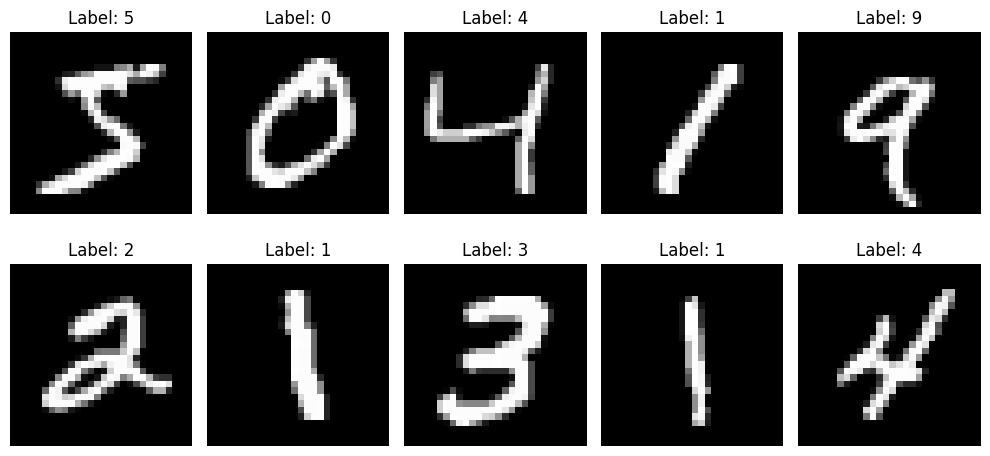

In [12]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [14]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9222 - loss: 0.2662 - val_accuracy: 0.9522 - val_loss: 0.1600
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9674 - loss: 0.1086 - val_accuracy: 0.9691 - val_loss: 0.1032
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9772 - loss: 0.0751 - val_accuracy: 0.9751 - val_loss: 0.0848
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9829 - loss: 0.0557 - val_accuracy: 0.9703 - val_loss: 0.1004
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9862 - loss: 0.0431 - val_accuracy: 0.9749 - val_loss: 0.0930
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9887 - loss: 0.0353 - val_accuracy: 0.9775 - val_loss: 0.0882
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9906 - loss: 0.0276 - val_accuracy: 0.9698 - val_loss: 0.1262
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9916 - loss: 0

In [17]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Original Model Test Accuracy:", test_accuracy)

Original Model Test Accuracy: 0.9787999987602234


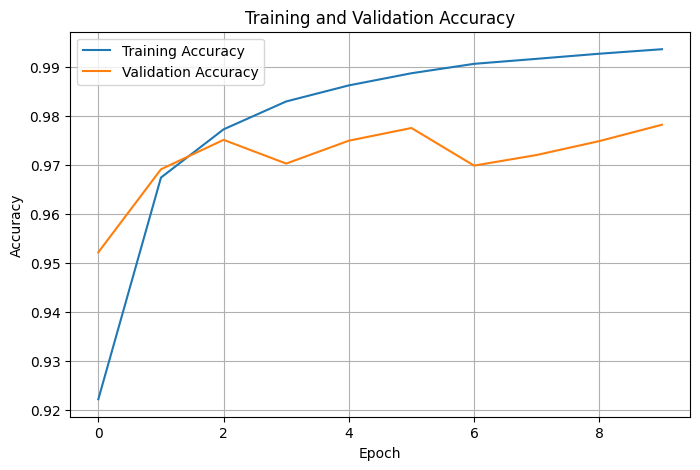

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

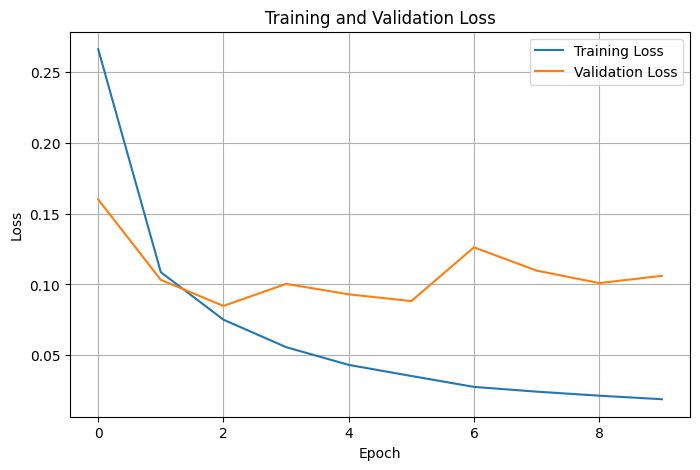

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()


In [20]:
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)

print("Actual Labels:   ", y_test[:5])
print("Predicted Labels:", predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
Actual Labels:    [7 2 1 0 4]
Predicted Labels: [7 2 1 0 4]


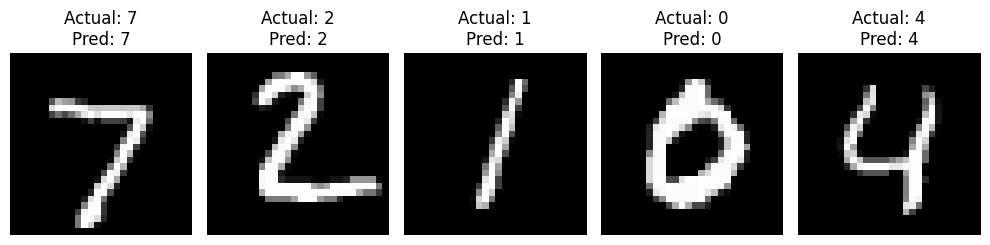

In [21]:
plt.figure(figsize=(10, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(
        f"Actual: {y_test[i]}\nPred: {predicted_labels[i]}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

In [22]:
experiment_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

experiment_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

experiment_history = experiment_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8890 - loss: 0.3696 - val_accuracy: 0.9560 - val_loss: 0.1492
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9463 - loss: 0.1772 - val_accuracy: 0.9673 - val_loss: 0.1120
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9591 - loss: 0.1360 - val_accuracy: 0.9688 - val_loss: 0.1060
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9653 - loss: 0.1126 - val_accuracy: 0.9682 - val_loss: 0.1071
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9691 - loss: 0.0989 - val_accuracy: 0.9712 - val_loss: 0.0940
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9729 - loss: 0.0871 - val_accuracy: 0.9748 - val_loss: 0.0878
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9759 - loss: 0.0793 - val_accuracy: 0.9750 - val_loss: 0.0932
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9776 - loss:

In [23]:
experiment_loss, experiment_accuracy = experiment_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Original Model Accuracy:", test_accuracy)
print("Dropout Model Accuracy:", experiment_accuracy)

Original Model Accuracy: 0.9787999987602234
Dropout Model Accuracy: 0.9778000116348267


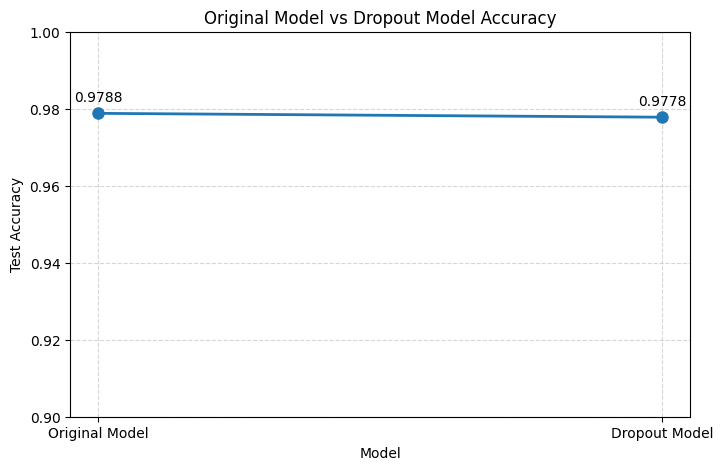

In [28]:
models = ['Original Model', 'Dropout Model']
accuracies = [test_accuracy, experiment_accuracy]

plt.figure(figsize=(8, 5))

plt.plot(
    models,
    accuracies,
    marker='o',
    linewidth=2,
    markersize=8
)

plt.title('Original Model vs Dropout Model Accuracy')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0.9, 1.0)

for i, accuracy in enumerate(accuracies):
    plt.text(
        i,
        accuracy + 0.003,
        f'{accuracy:.4f}',
        ha='center'
    )

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()